In [10]:
from google.colab import files
uploaded = files.upload()

Saving letter-recognition.csv to letter-recognition.csv
Saving iris.csv to iris (1).csv


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [12]:
# Load dataset
iris = pd.read_csv("iris.csv")

# Features & target
X_iris = iris.iloc[:, :-1]
y_iris = iris.iloc[:, -1]

# Train-test split (80-20)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_i = scaler.fit_transform(X_train_i)
X_test_i = scaler.transform(X_test_i)

# -------- Linear Kernel --------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_i, y_train_i)

y_pred_linear = svm_linear.predict(X_test_i)

print("===== IRIS (LINEAR) =====")
print("Accuracy:", accuracy_score(y_test_i, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test_i, y_pred_linear))


# -------- RBF Kernel --------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_i, y_train_i)

y_pred_rbf = svm_rbf.predict(X_test_i)

print("\n===== IRIS (RBF) =====")
print("Accuracy:", accuracy_score(y_test_i, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test_i, y_pred_rbf))

===== IRIS (LINEAR) =====
Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

===== IRIS (RBF) =====
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [13]:
# Load dataset
letter = pd.read_csv("letter-recognition.csv")

# First column = target (letters), rest = features
X_letter = letter.iloc[:, 1:]
y_letter = letter.iloc[:, 0]

# Encode target (A-Z → numbers)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_letter = le.fit_transform(y_letter)

# Train-test split
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_letter, y_letter, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_l = scaler.fit_transform(X_train_l)
X_test_l = scaler.transform(X_test_l)

# Train SVM (RBF kernel + probability for ROC)
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_l, y_train_l)

# Predictions
y_pred_l = svm_model.predict(X_test_l)

print("\n===== LETTER DATASET =====")
print("Accuracy:", accuracy_score(y_test_l, y_pred_l))
print("Confusion Matrix:\n", confusion_matrix(y_test_l, y_pred_l))


===== LETTER DATASET =====
Accuracy: 0.95
Confusion Matrix:
 [[148   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  1 147   0   3   0   0   0   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [  0   0 126   0   2   0   2   1   0   0   2   0   0   0   4   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   1   0 153   0   0   0   1   0   0   0   0   0   1   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   1   0 135   0   3   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   1   0   0   1 134   0   0   1   0   0   0   0   0   0   1   0   0
    0   2   0   0   0   0   0   0]
 [  0   0   1   3   0   0 153   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   3   0   4   0   0   1 118   0   0   4   0   0   1   2   0   0   8
    0   0   1   0   0   1   1   0]
 [  0   0   0   0   0   2   0   0 136   7   0   0   0   0   0   0 

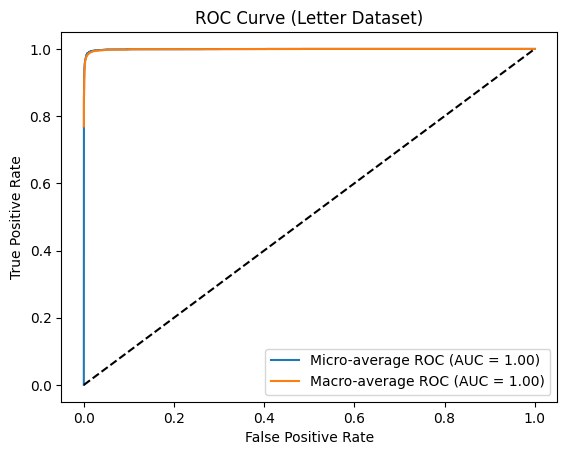

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Binarize labels
y_test_bin = label_binarize(y_test_l, classes=np.unique(y_letter))
n_classes = y_test_bin.shape[1]

# Predict probabilities
y_score = svm_model.predict_proba(X_test_l)

# -------- MICRO-AVERAGE ROC --------
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# -------- MACRO-AVERAGE ROC --------
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Aggregate all FPR points
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

roc_auc_macro = auc(all_fpr, mean_tpr)

# -------- PLOT --------
plt.figure()

# Micro-average
plt.plot(fpr_micro, tpr_micro,
         label=f"Micro-average ROC (AUC = {roc_auc_micro:.2f})")

# Macro-average
plt.plot(all_fpr, mean_tpr,
         label=f"Macro-average ROC (AUC = {roc_auc_macro:.2f})")

# Diagonal
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Letter Dataset)")
plt.legend()
plt.show()